In [14]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import math
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.visualization import plot_histogram

In [68]:
def qft_dagger(qc, n):
    """n-qubit QFTdagger the first n qubits in circ"""
    # Don't forget the Swaps!
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-math.pi/float(2**(j-m)), m, j)
        qc.h(j)

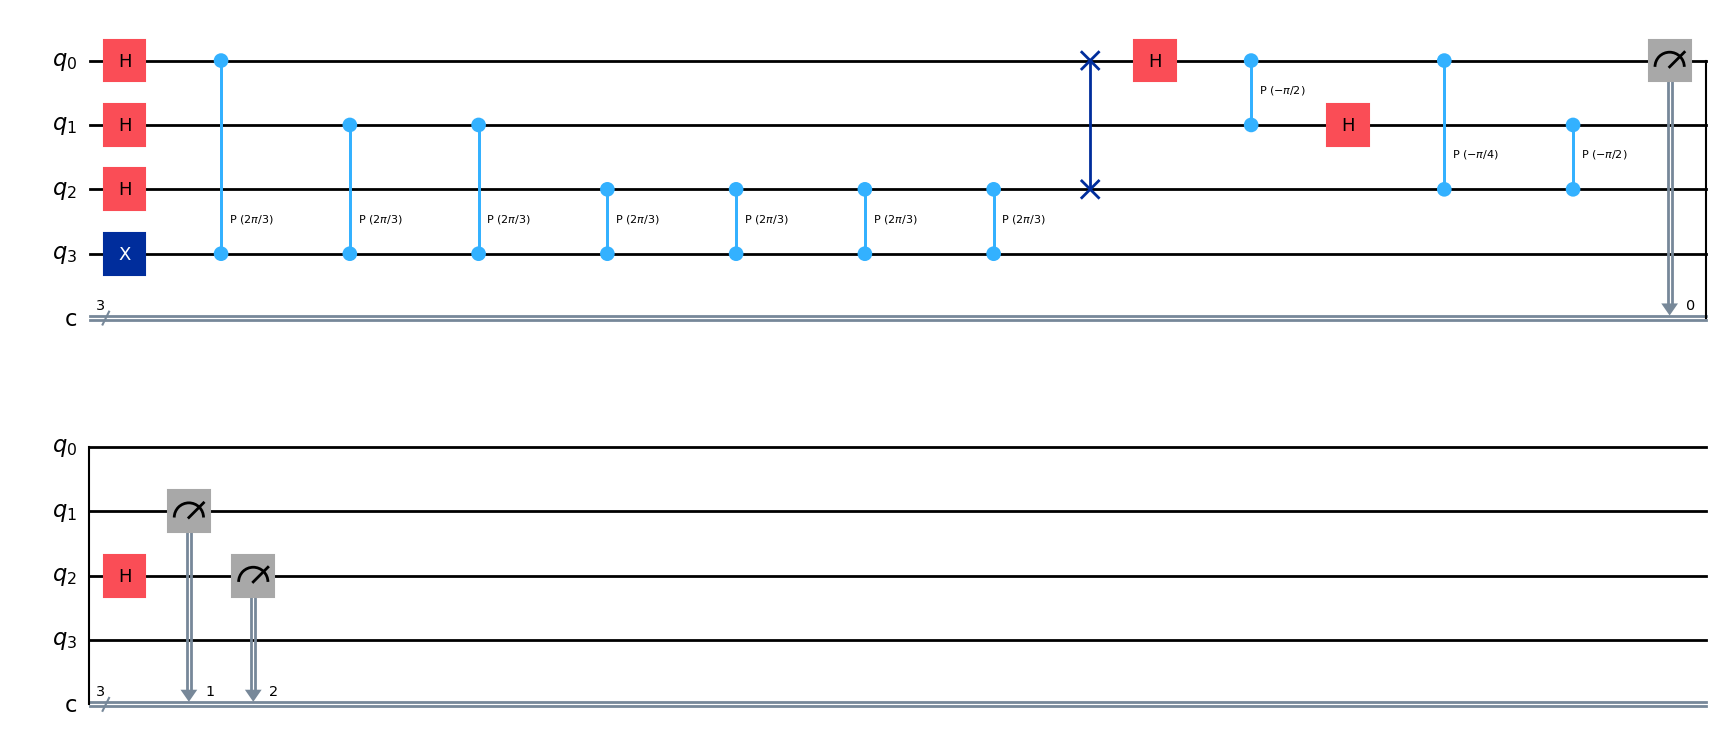

In [71]:
# Create and set up circuit
qpe3 = QuantumCircuit(4, 3)

# Apply H-Gates to counting qubits:
for qubit in range(3):
    qpe3.h(qubit)

# Prepare our eigenstate |psi>:
qpe3.x(3)

# Do the controlled-U operations:
angle = 2*math.pi/3
repetitions = 1
for counting_qubit in range(3):
    for i in range(repetitions):
        qpe3.cp(angle, counting_qubit, 3);
    repetitions *= 2

# Do the inverse QFT:
qft_dagger(qpe3, 3)

# Measure of course!
for n in range(3):
    qpe3.measure(n,n)

qpe3.draw("mpl")

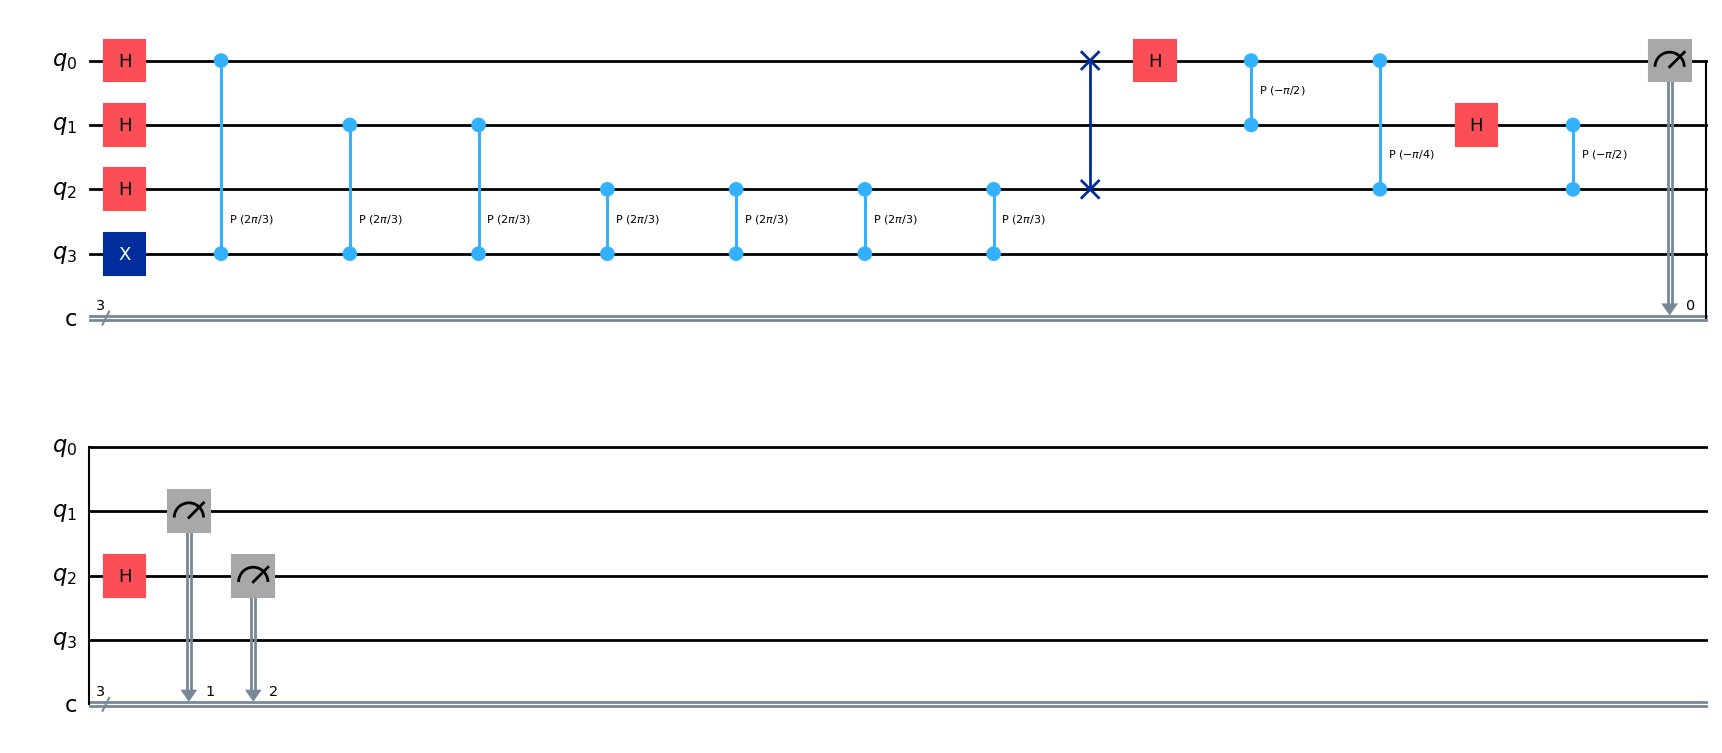

In [72]:
# Transpilation step: this takes the circuit and gives the alternative suitable circuit which can be executed on the backend
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Initialize the AerSimulator backend
aer_sim = AerSimulator()

# Generate a preset pass manager for transpilation
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
isa_qpe = pm.run(qpe3)  # Transpiled version of the circuit qc
# Draw the transpiled quantum circuit
isa_qpe.draw("mpl", idle_wires=False)




In [90]:
# Create the sampler and execute with a higher number of shots for better statistics
t=3
sampler = Sampler(aer_sim)
num_shots = 10000# You can adjust this number if needed

# Run the sampler with the specified number of shots
result = sampler.run([isa_qpe], shots=num_shots).result()

# Print the results
print("Results", result)

# Retrieve the counts from the result
pub_result = result[0]
counts = pub_result.data.c.get_counts()

# To display counts for all possible states (e.g., for 10 control qubits, there are 2^10 = 1024 possible states)
all_possible_states = [format(i, f'0{t}b') for i in range(2 ** t)]  # Generate all possible states in binary

# Display counts including zero counts
final_counts = {state: counts.get(state, 0) for state in all_possible_states}

# Print the counts for all states
print(f"Counts for all output states: {final_counts}")

Results PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=10000, num_bits=3>)), metadata={'shots': 10000, 'circuit_metadata': {}})], metadata={'version': 2})
Counts for all output states: {'000': 166, '001': 311, '010': 1745, '011': 6837, '100': 505, '101': 160, '110': 151, '111': 125}


In [91]:
final_counts = {state: counts.get(state, 0) for state in all_possible_states}


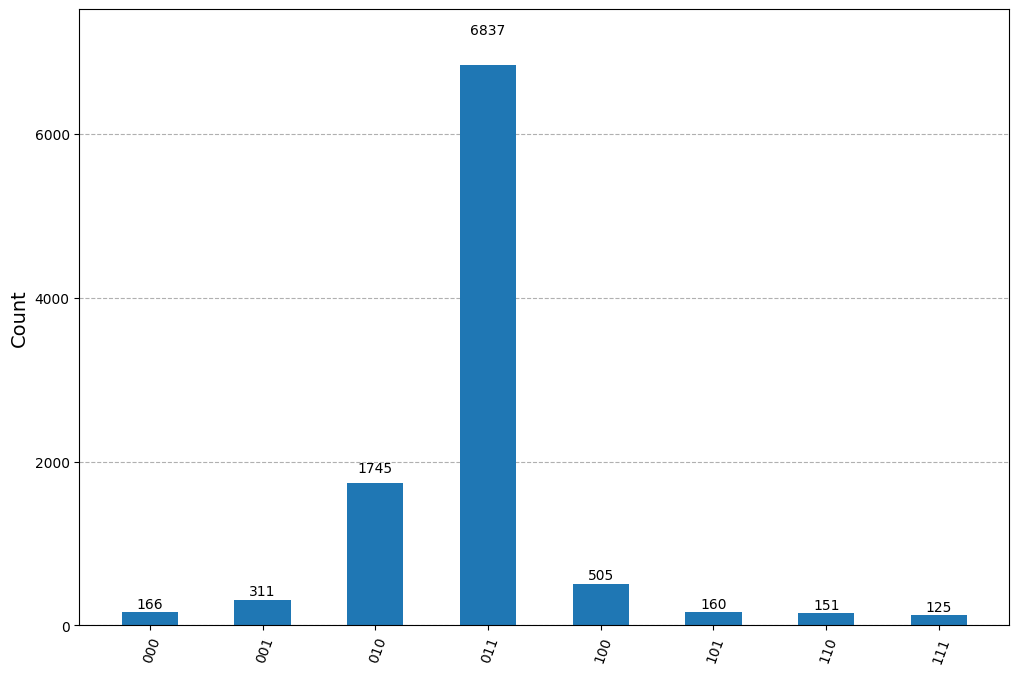

In [92]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Generate the histogram with customized size and resolution
plot_histogram(final_counts, figsize=(12, 8))  # Adjust `figsize` and `dpi` as needed